In [84]:
import pandas as pd
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc
import shap


In [27]:
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')
df_train_merged = pd.read_csv('data/train_merged.csv')

In [28]:
TARGET = 'PitNextLap'
TARGET = 'ground_truth'


In [29]:
import pandas as pd
import glob
import os

folder = r"Sampling_data_to_test"

files = glob.glob(os.path.join(folder, "*.csv"))

df = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index=True
)

output = os.path.join("external/Sampling_merged.csv")
df.to_csv(output, index=False)

print(f"Merged {len(files)} CSV files")
print(f"Total rows: {len(df)}")
print(f"Saved: {output}")

Merged 5 CSV files
Total rows: 50000
Saved: external/Sampling_merged.csv


In [30]:
df_sampling_test = pd.read_csv("external/Sampling_merged.csv")

In [ ]:
predictor = TabularPredictor.load("ag_models5")
predictor.info()

In [4]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.959994,roc_auc,22.646903,1704.332377,0.049652,5.011189,2,True,5
1,XGBoost_BAG_L1,0.958240,roc_auc,4.327017,558.767684,4.327017,558.767684,1,True,4
2,CatBoost_BAG_L1,0.958136,roc_auc,4.220672,966.620621,4.220672,966.620621,1,True,3
3,LightGBMLarge_BAG_L1,0.952897,roc_auc,14.049562,173.932884,14.049562,173.932884,1,True,2
4,LightGBM_BAG_L1,0.951028,roc_auc,5.040709,87.416877,5.040709,87.416877,1,True,1


In [7]:
# Compute permutation feature importance on holdout/validation/test data
# Pass your validation/test set to get unbiased estimates
feature_importance = predictor.feature_importance(
    data=df_train,  # Or test_data
    subsample_size=10000,  # Limits sample size for speed (increase or set to None for higher precision)
    num_shuffle_sets=5,  # Number of times to shuffle each feature to reduce variance
)

print(feature_importance)

These features in provided data are not utilized by the predictor and will be ignored: ['id']


                        importance    stddev       p_value  n  p99_high  \
TyreLife                  0.159883  0.003362  2.345985e-08  5  0.166806   
Stint                     0.076329  0.005417  3.023013e-06  5  0.087483   
Year                      0.057592  0.002855  7.223980e-07  5  0.063470   
RaceProgress              0.039936  0.000872  2.720627e-08  5  0.041730   
LapNumber                 0.025291  0.001202  6.098602e-07  5  0.027765   
Race                      0.024201  0.000823  1.603375e-07  5  0.025896   
LapTime_Delta             0.020679  0.001940  9.192064e-06  5  0.024675   
Cumulative_Degradation    0.011112  0.000583  9.081003e-07  5  0.012313   
Driver                    0.009661  0.000491  7.968977e-07  5  0.010672   
LapTime (s)               0.007157  0.000560  4.468164e-06  5  0.008310   
Position                  0.007061  0.000615  6.842515e-06  5  0.008327   
Position_Change           0.006375  0.000379  1.489577e-06  5  0.007156   
Compound                 

In [10]:
leaderboard = predictor.leaderboard(
    data=df_train.head(100000), silent=False, extra_info=True  # Set True to see hyperparameters per model
)

                  model  score_test  score_val eval_metric  pred_time_test  pred_time_val     fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order  num_features  num_models  num_models_w_ancestors  memory_size  memory_size_w_ancestors  memory_size_min  memory_size_min_w_ancestors  num_ancestors  num_descendants             model_type             child_model_type stopping_metric                                    hyperparameters hyperparameters_fit                                        ag_args_fit                                           features compile_time                              child_hyperparameters  child_hyperparameters_fit                                  child_ag_args_fit                                          ancestors            descendants
0       LightGBM_BAG_L1    0.982530   0.951028     roc_auc        7.930235       5.040709    87.416877                 7.930235                5.040709          87.416877 

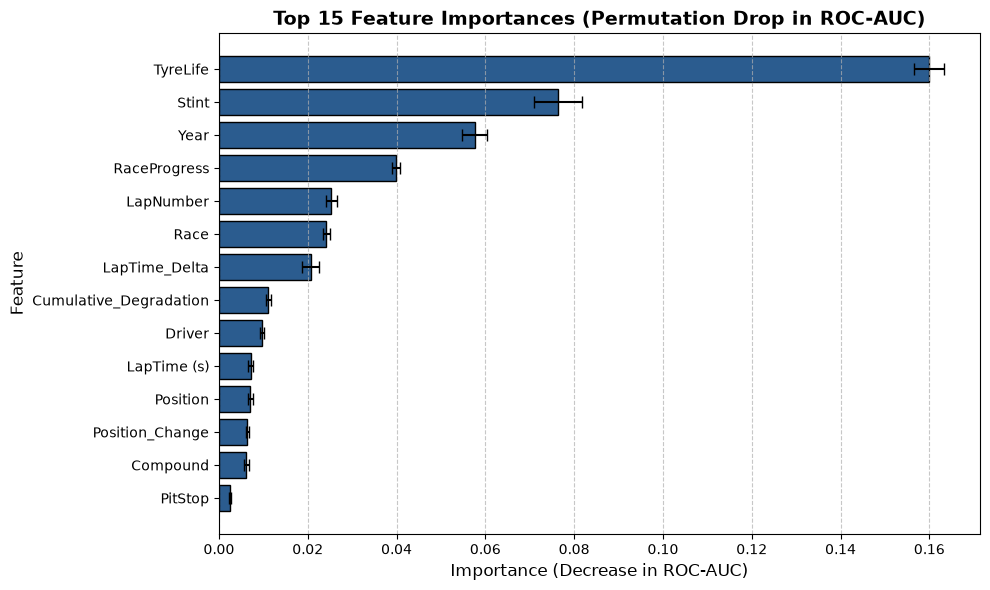

In [13]:
# Select top 15 features
top_fi = feature_importance.head(15).reset_index()

plt.figure(figsize=(10, 6))
bars = plt.barh(
    y=top_fi["index"],
    width=top_fi["importance"],
    xerr=top_fi["stddev"],
    capsize=4,
    color="#2b5c8f",
    edgecolor="black",
)

plt.gca().invert_yaxis()  # Highest importance at top
plt.title("Top 15 Feature Importances (Permutation Drop in ROC-AUC)", fontsize=14, fontweight="bold")
plt.xlabel("Importance (Decrease in ROC-AUC)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23100\3244566947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


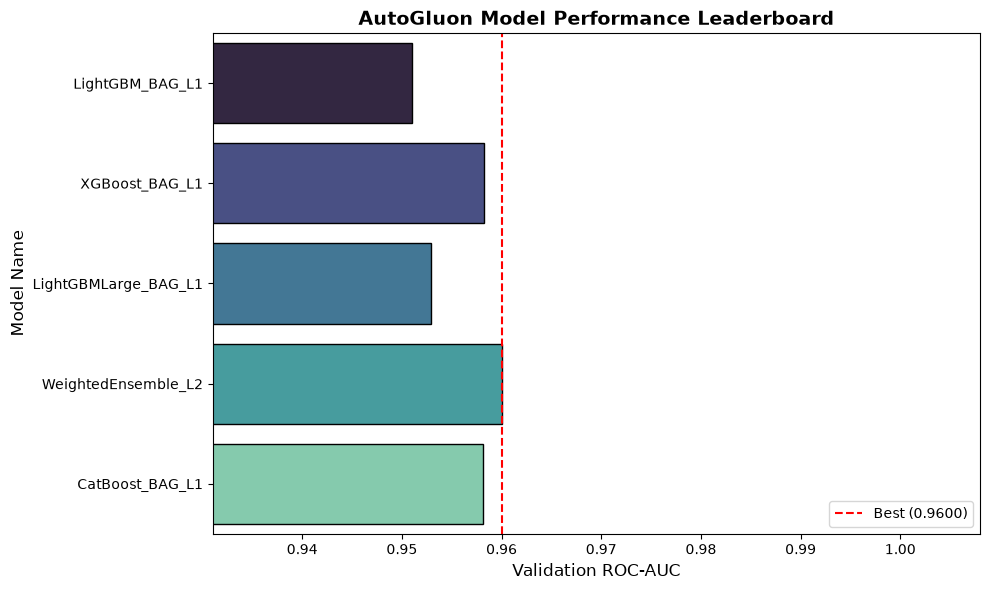

In [14]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x="score_val",
    y="model",
    data=leaderboard,
    palette="mako",
    edgecolor="black",
)

# Highlight best model score
best_score = leaderboard["score_val"].max()
plt.axvline(best_score, color="red", linestyle="--", label=f"Best ({best_score:.4f})")

plt.xlim(left=max(0, leaderboard["score_val"].min() - 0.02))
plt.title("AutoGluon Model Performance Leaderboard", fontsize=14, fontweight="bold")
plt.xlabel("Validation ROC-AUC", fontsize=12)
plt.ylabel("Model Name", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
y_true = df_sampling_test[TARGET]
y_probs = predictor.predict_proba(df_sampling_test)[1]
y_preds = predictor.predict(df_sampling_test)





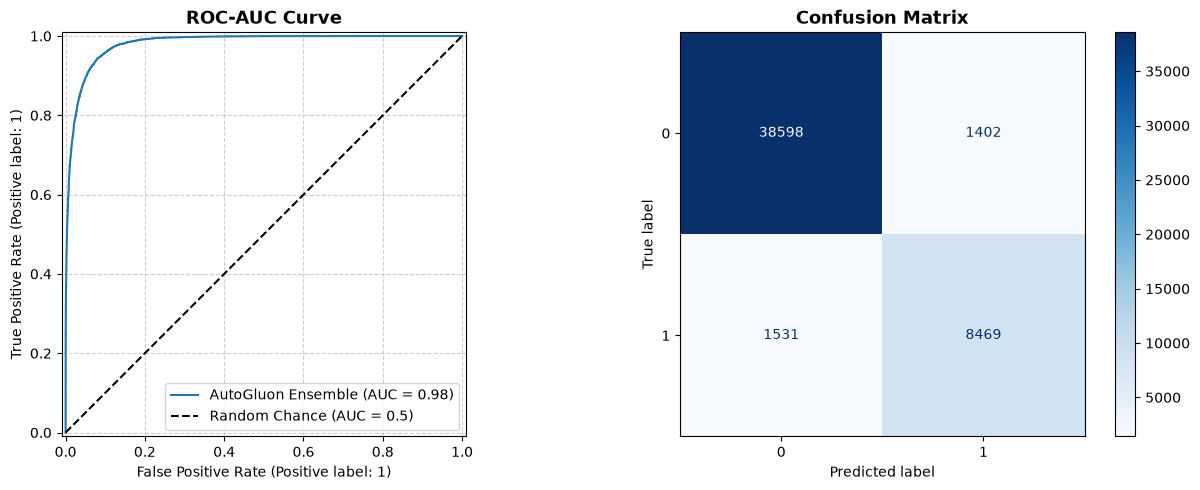

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# ROC Curve
roc = RocCurveDisplay.from_predictions(
    y_true,
    y_probs,
    ax=axes[0],
    name="AutoGluon Ensemble"
)

roc.line_.set_color("#1f77b4")
axes[0].plot([0, 1], [0, 1], "k--", label="Random Chance (AUC = 0.5)")
axes[0].set_title("ROC-AUC Curve", fontsize=13, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_true, y_preds, ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import pandas as pd
import shap
import torch
# Ensure PyTorch utilizes CUDA for neural network models in the ensemble
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [52]:
# 1. Prepare raw sample data
X_val = df_sampling_test.drop(columns=[TARGET])
test_samples = X_val.sample(n=min(30, len(X_val)), random_state=42)
background_data = shap.sample(X_val, 10)


# 2. Direct AutoGluon predict_proba wrapper
def predict_fn(x):
    if not isinstance(x, pd.DataFrame):
        x = pd.DataFrame(x, columns=test_samples.columns)
    return predictor.predict_proba(x)[1].values


# 3. Run KernelExplainer
explainer = shap.KernelExplainer(predict_fn, background_data)
raw_shap_values = explainer.shap_values(test_samples)






100%|██████████| 30/30 [05:56<00:00, 11.89s/it]


In [53]:
# 3. Run KernelExplainer
explainer = shap.KernelExplainer(predict_fn, background_data)
raw_shap_values = explainer.shap_values(test_samples)


100%|██████████| 30/30 [05:18<00:00, 10.61s/it]


In [54]:
# 4. Convert NumPy output into a shap.Explanation object
shap_explanation = shap.Explanation(
    values=raw_shap_values,
    base_values=explainer.expected_value,
    data=test_samples.values,
    feature_names=test_samples.columns,
)

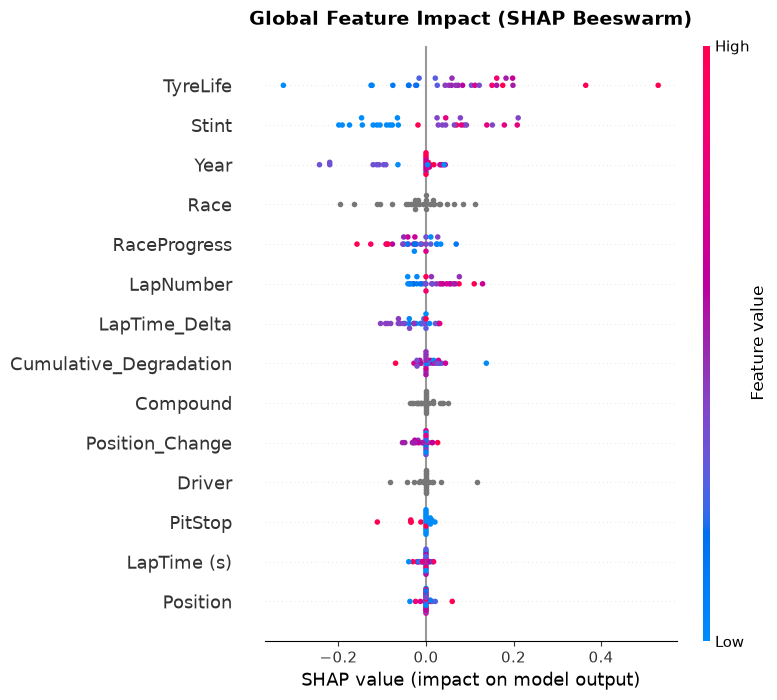

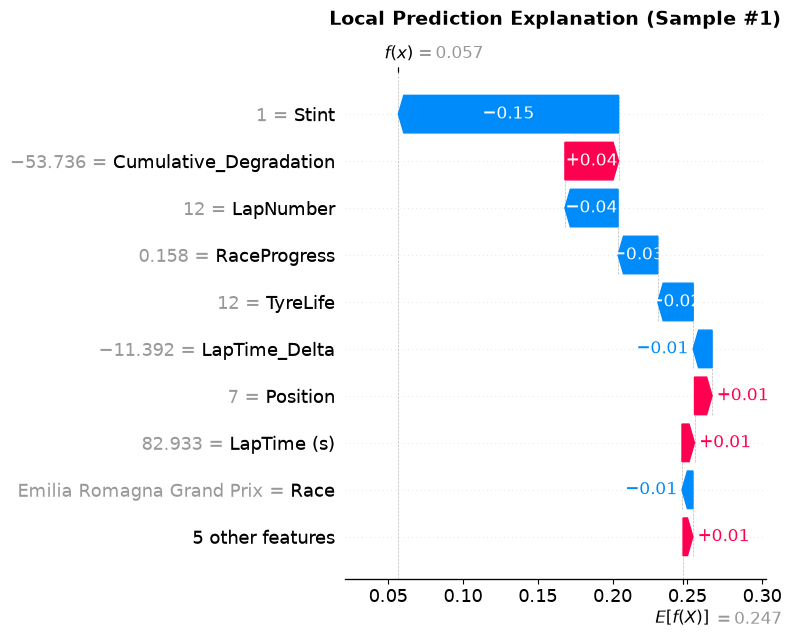

In [59]:

# 5. Global Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title(
    "Global Feature Impact (SHAP Beeswarm)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()




# 6. Local Waterfall Plot (First Sample)
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_explanation[0], show=False)
plt.title(
    "Local Prediction Explanation (Sample #1)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()




In [ ]:
predictor.info()

In [ ]:
## Importance for each model

Disk models :  ['CatBoost_BAG_L1', 'LightGBMLarge_BAG_L1', 'LightGBM_BAG_L1', 'trainer.pkl', 'WeightedEnsemble_L2', 'XGBoost_BAG_L1']
Total models found: 5
Models in ag_models5/models/: ['CatBoost_BAG_L1', 'LightGBMLarge_BAG_L1', 'LightGBM_BAG_L1', 'trainer.pkl', 'WeightedEnsemble_L2', 'XGBoost_BAG_L1']
WeightedEnsemble_L2

Ensemble Base Model Weights:


In [70]:
all_models = predictor.model_names()
print("All trained models:", all_models)

All trained models: ['LightGBM_BAG_L1', 'LightGBMLarge_BAG_L1', 'CatBoost_BAG_L1', 'XGBoost_BAG_L1', 'WeightedEnsemble_L2']


In [78]:
df_sampling_test_all_models = df_sampling_test.copy()
df_sampling_test_all_models = df_sampling_test_all_models.rename({"ground_truth":"PitNextLap"}, axis=1)
df_sampling_test_all_models.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D015,MEDIUM,French Grand Prix,2022,0,13,1,13.0,9,100.822,28.067,-61.861,0.180556,2.0,0
1,D034,MEDIUM,Emilia Romagna Grand Prix,2024,0,24,1,24.0,10,86.837,2.201,-75.086,0.338028,1.0,0
2,D336,HARD,Hungarian Grand Prix,2023,0,35,2,26.0,1,83.973,-0.097,-18.081,0.500000,0.0,0
3,ALO,MEDIUM,Pre-Season Testing,2025,1,50,2,24.0,8,95.962,6.642,-197.343,0.694444,-2.0,0
4,PER,HARD,Canadian Grand Prix,2025,0,25,1,25.0,7,79.277,-15.053,-105.149,0.347222,2.0,0


In [80]:
results = []
for model_name in predictor.model_names():
    # Evaluate each model individually on validation/test set
    perf = predictor.evaluate(df_sampling_test_all_models, model=model_name, silent=True)
    results.append(
        {
            "Model": model_name,
            "ROC_AUC": perf["roc_auc"],
            "Accuracy": perf.get("accuracy", None),
            "LogLoss": perf.get("log_loss", None),
        }
    )


df_all_eval = (
    pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
)
print(df_all_eval)

                  Model   ROC_AUC  Accuracy LogLoss
0       LightGBM_BAG_L1  0.985987   0.94876    None
1        XGBoost_BAG_L1  0.984918   0.94818    None
2  LightGBMLarge_BAG_L1  0.983317   0.94406    None
3   WeightedEnsemble_L2  0.981544   0.94134    None
4       CatBoost_BAG_L1  0.972474   0.92928    None


In [89]:
all_probas = {}

for model_name in predictor.model_names():
    # Get class 1 probabilities for each model
    all_probas[model_name] = predictor.predict_proba(df_sampling_test_all_models, model=model_name)[1]

df_all_probas = pd.DataFrame(all_probas)
df_all_probas.head(10)

,LightGBM_BAG_L1,LightGBMLarge_BAG_L1,CatBoost_BAG_L1,XGBoost_BAG_L1,WeightedEnsemble_L2
0,0.006361,0.011668,0.014241,0.011685,0.012809
1,0.029344,0.046283,0.033533,0.050936,0.042906
2,0.002006,0.002508,0.008692,0.002930,0.005432
3,0.140457,0.218329,0.183255,0.140628,0.165600
4,0.056248,0.070340,0.061985,0.049152,0.056494
5,0.156296,0.160378,0.103446,0.136955,0.124085
6,0.142226,0.066983,0.116959,0.096968,0.103365
7,0.029884,0.040971,0.025350,0.041979,0.034581
8,0.594418,0.680754,0.779404,0.560058,0.666226
9,0.096014,0.107962,0.082372,0.146531,0.115216


<Figure size 1000x700 with 0 Axes>

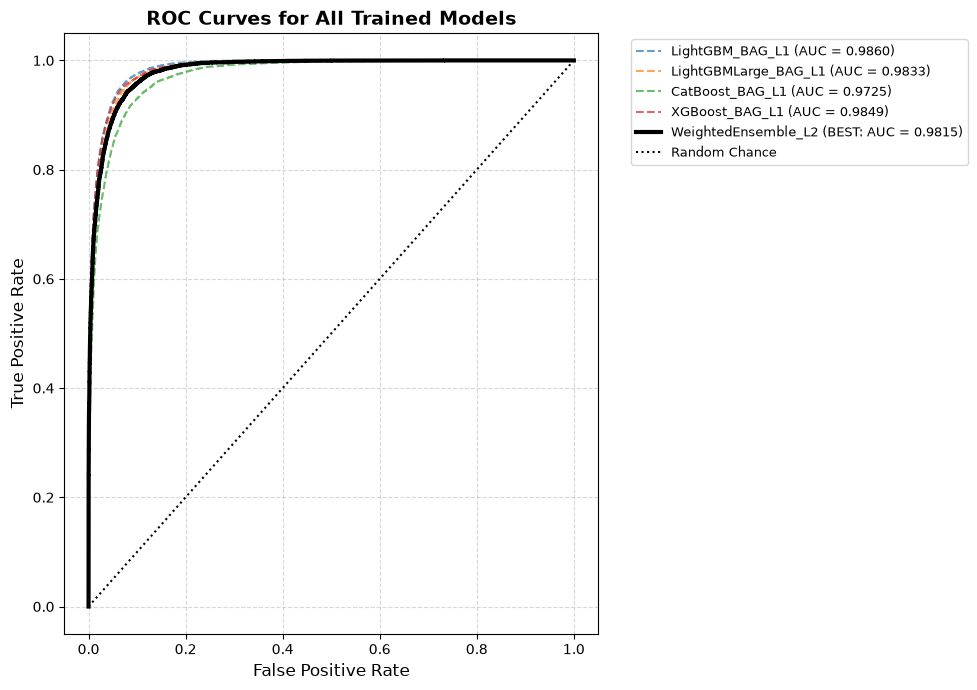

In [86]:

# Plot ROC Curves for All Models Side-by-Side
TARGET = "PitNextLap"
plt.figure(figsize=(10, 7))

for model_name in predictor.model_names():
    y_proba = predictor.predict_proba(df_sampling_test_all_models, model=model_name)[1]
    fpr, tpr, _ = roc_curve(df_sampling_test_all_models[TARGET], y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Highlight the best model with a thicker line
    if model_name == predictor.model_best:
        plt.plot(fpr, tpr, label=f"{model_name} (BEST: AUC = {roc_auc:.4f})", linewidth=3, color="black")
    else:
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})", alpha=0.7, linestyle="--")

plt.plot([0, 1], [0, 1], "k:", label="Random Chance")
plt.title("ROC Curves for All Trained Models", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate Feature Importance for Each Base Model
# Compute feature importance for every individual model
model_feature_importances = {}

for model_name in predictor.model_names():
    # Limit subsample_size for faster execution if you have many models
    fi = predictor.feature_importance(
        data=df_sampling_test_all_models,
        model=model_name,
        subsample_size=1000,
        silent=True
    )
    model_feature_importances[model_name] = fi['importance']

# Combine into a single comparison DataFrame
df_fi_comparison = pd.DataFrame(model_feature_importances)


In [88]:
df_fi_comparison.head(15)

,LightGBM_BAG_L1,LightGBMLarge_BAG_L1,CatBoost_BAG_L1,XGBoost_BAG_L1,WeightedEnsemble_L2
Compound,0.002399,0.007835,0.010894,0.006031,0.006920
Cumulative_Degradation,0.006769,0.008032,0.009002,0.015643,0.012118
Driver,0.047498,0.034120,0.014238,0.011406,0.013768
LapNumber,0.009142,0.007602,0.029945,0.026631,0.020062
LapTime (s),0.003922,0.002443,0.004229,0.011991,0.007397
LapTime_Delta,0.015497,0.014913,0.018779,0.023768,0.020214
PitStop,0.001662,0.002939,0.002244,0.001368,0.001792
Position,0.004749,0.007577,0.006270,0.009705,0.007819
Position_Change,0.004998,0.004742,0.004689,0.008546,0.006780
Race,0.041793,0.049854,0.036147,0.023159,0.027818


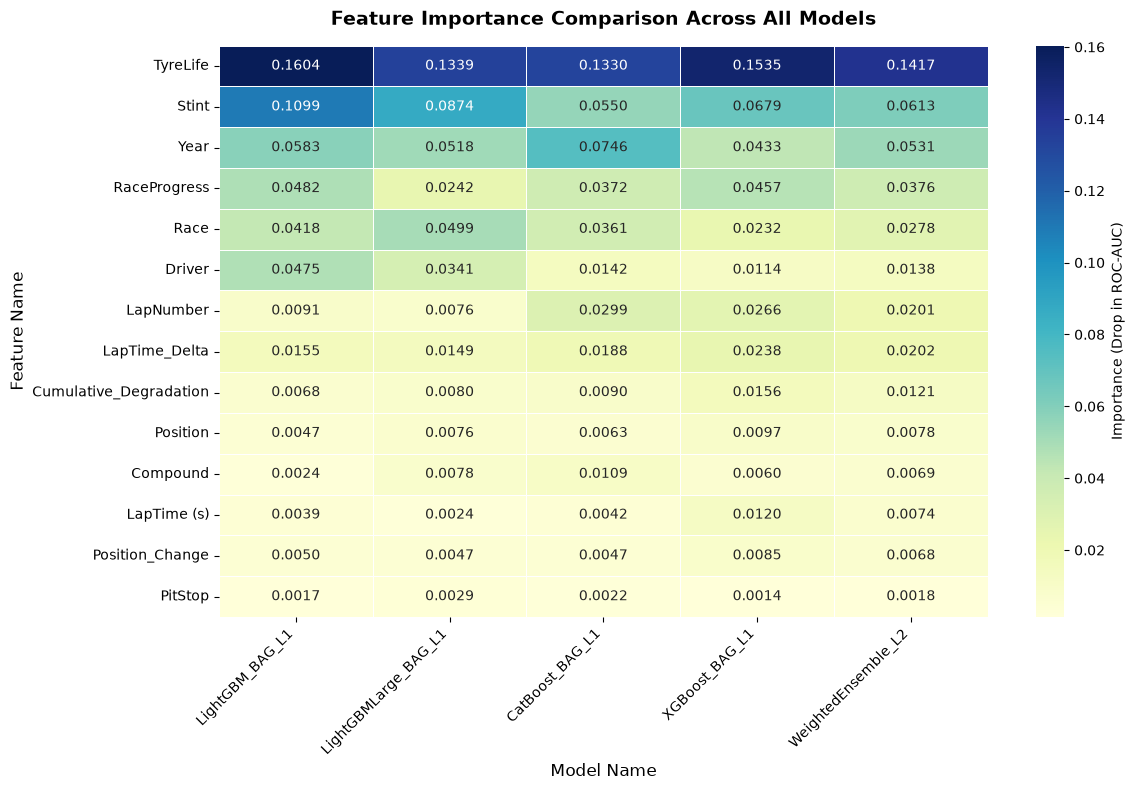

In [90]:
# Select top 15 features based on average importance across models
top_features = (
    df_fi_comparison.mean(axis=1).sort_values(ascending=False).head(15).index
)
df_fi_top = df_fi_comparison.loc[top_features]

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_fi_top,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar_kws={"label": "Importance (Drop in ROC-AUC)"},
    linewidths=0.5,
)

plt.title(
    "Feature Importance Comparison Across All Models",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Model Name", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

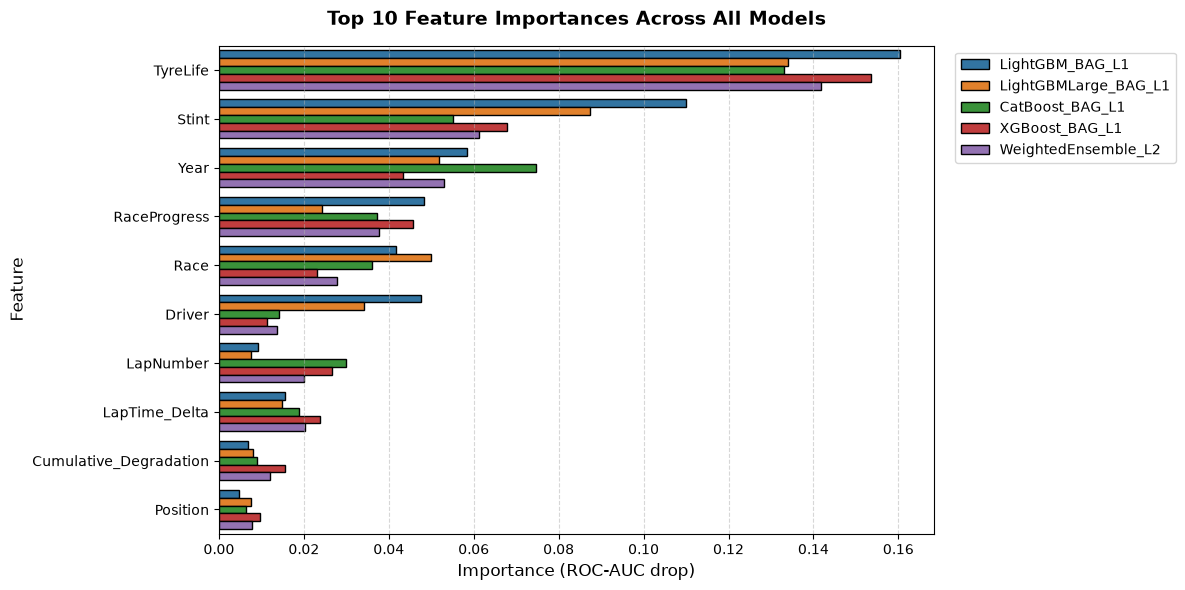

In [91]:
# Melt dataframe for grouped bar chart plotting
top_10_features = (
    df_fi_comparison.mean(axis=1).sort_values(ascending=False).head(10).index
)
df_fi_melted = (
    df_fi_comparison.loc[top_10_features]
    .reset_index()
    .melt(id_vars="index", var_name="Model", value_name="Importance")
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_fi_melted,
    x="Importance",
    y="index",
    hue="Model",
    palette="tab10",
    edgecolor="black",
)

plt.title(
    "Top 10 Feature Importances Across All Models",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Importance (ROC-AUC drop)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()